### Import the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

### Load the Data and Merge into 1 DataFrame

In [2]:
df_train = pd.read_csv("../data/student_train.csv")
df_cov = pd.read_csv("../data/optional_external_data.csv")

df = pd.merge(df_train, df_cov, on="time_idx", how="left")

### Target Distribution and Trend

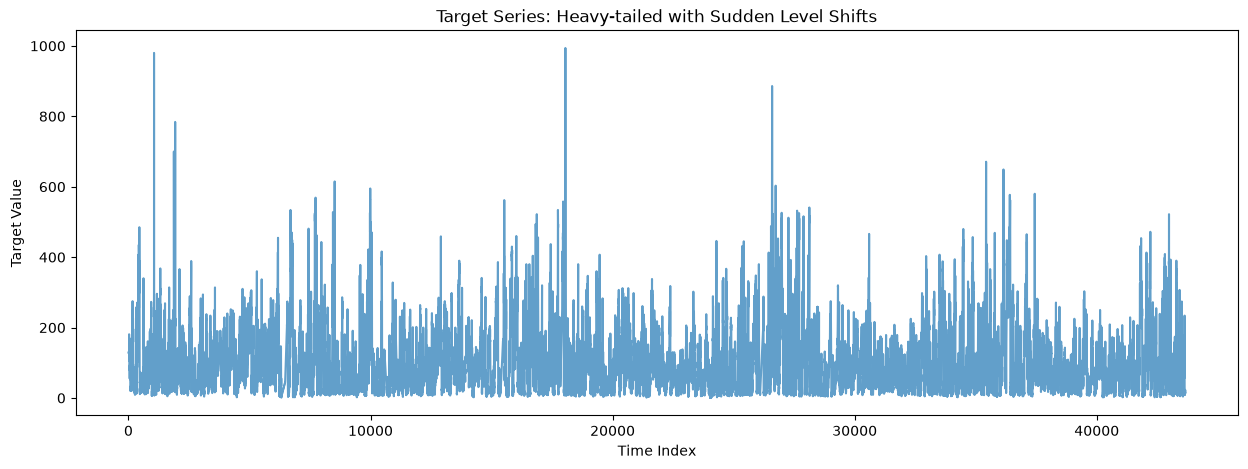

In [3]:
plt.figure(figsize=(15, 5))
plt.plot(df['time_idx'], df['value'], alpha=0.7)
plt.title("Target Series: Heavy-tailed with Sudden Level Shifts")
plt.xlabel("Time Index")
plt.ylabel("Target Value")
plt.savefig("../results/eda_target_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

### Autocorrelation Analysis

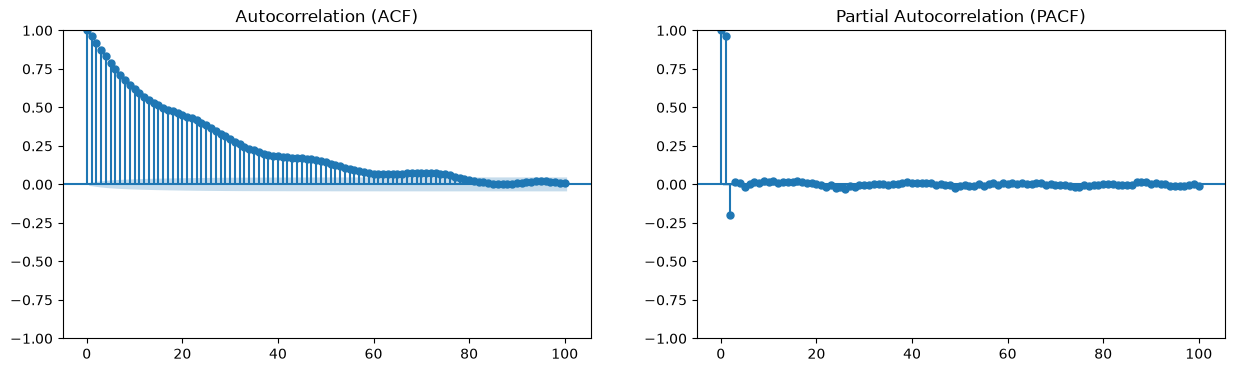

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(df['value'], lags=100, ax=ax[0], title="Autocorrelation (ACF)")
plot_pacf(df['value'], lags=100, ax=ax[1], title="Partial Autocorrelation (PACF)")
plt.savefig("../results/eda_autocorrelation.png", dpi=300, bbox_inches='tight')
plt.show()

### Covariate Analysis: Binary Indicators

Detected Binary Columns: ['feature_G', 'feature_H', 'feature_I', 'feature_J']


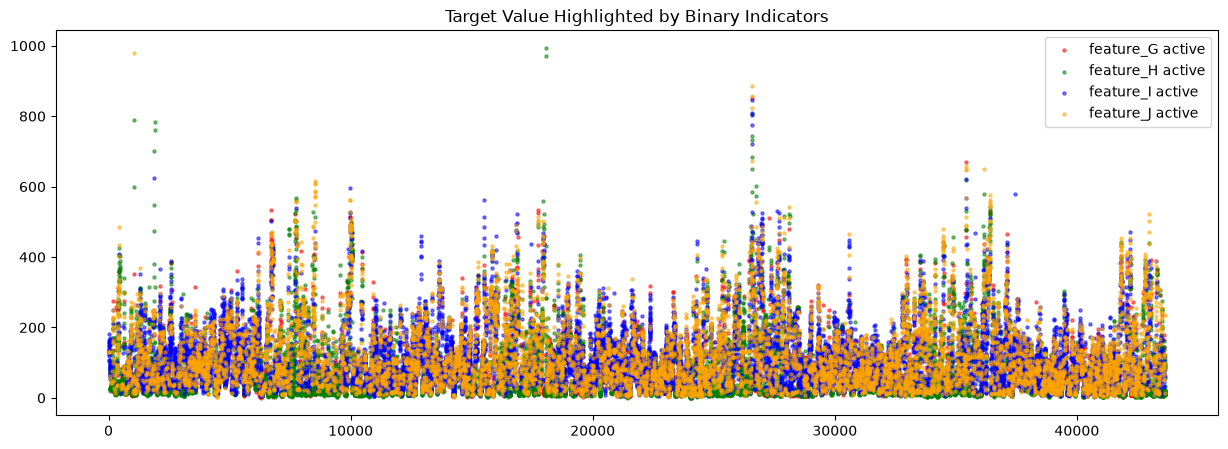

In [5]:
binary_cols = [col for col in df_cov.columns if df_cov[col].nunique() == 2]
print(f"Detected Binary Columns: {binary_cols}")

plt.figure(figsize=(15, 5))
colors = ['red', 'green', 'blue', 'orange']
for i, col in enumerate(binary_cols):
    subset = df[df[col] == 1]
    plt.scatter(subset['time_idx'], subset['value'], s=5, label=f"{col} active", color=colors[i], alpha=0.5)
plt.title("Target Value Highlighted by Binary Indicators")
plt.legend()
plt.savefig("../results/eda_binary_indicators.png", dpi=300, bbox_inches='tight')
plt.show()

### Covariate Analysis: Continuous Indicators

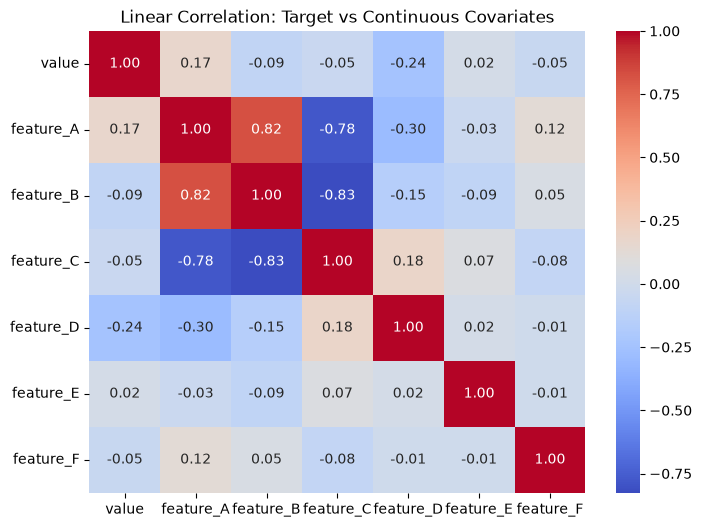

In [6]:
continuous_cols = [col for col in df_cov.columns if col not in binary_cols and col != 'time_idx']
corr_matrix = df[['value'] + continuous_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Linear Correlation: Target vs Continuous Covariates")
plt.savefig("../results/eda_continuous_indicators.png", dpi=300, bbox_inches='tight')
plt.show()